In [42]:
from risk_experiment.utils.data import get_all_behavior, get_all_subjects
import pandas as pd
import seaborn as sns

bids_folder = '/data/ds-risk'

In [52]:
drop_outliers = True
session = None
df = get_all_behavior(sessions=session, bids_folder=bids_folder, drop_outliers=False)

100%|██████████| 30/30 [00:01<00:00, 21.35it/s]


In [53]:
decoding_info_3t = pd.concat([sub.get_decoding_info('3t2', mask='npcr', n_voxels=0.0) for sub in get_all_subjects(bids_folder)])
decoding_info_7t = pd.concat([sub.get_decoding_info('7t2', mask='npcr', n_voxels=0.0) for sub in get_all_subjects(bids_folder)])
decoding_info = pd.concat((decoding_info_3t, decoding_info_7t))

In [54]:
df = df.join(decoding_info)
df['median_split(sd)'] = df.groupby(['subject', 'session', 'n1', 'risky_first'], group_keys=False)['sd'].apply(lambda d: d>d.quantile())
df['median_split_sd'] = df['median_split(sd)']

In [55]:
df['expected_payoff'] = (df['n_risky'] * .55).where(df['chose_risky'], df['n_safe'])

<Axes: xlabel='median_split(sd)', ylabel='expected_payoff'>

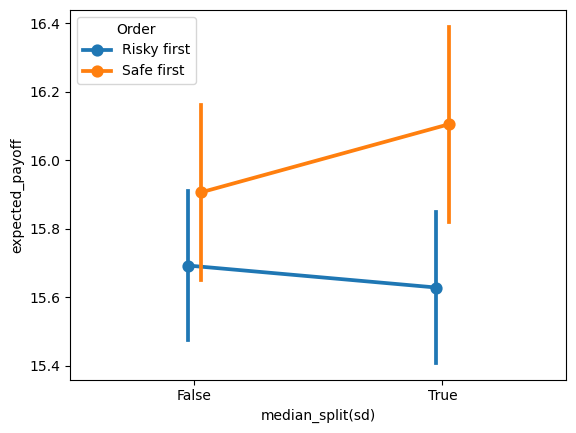

In [63]:
tmp = df.groupby(['subject', 'median_split(sd)', 'Order'])[['expected_payoff']].mean()
sns.pointplot(data=tmp, x='median_split(sd)', y='expected_payoff', hue='Order', dodge=True, errorbar='se')

In [64]:
import pingouin as pg

pg.pairwise_tests(tmp.reset_index(), dv='expected_payoff', between='median_split(sd)', parametric=False, subject='subject')

,Contrast,A,B,Paired,Parametric,U-val,alternative,p-unc,hedges
0,median_split(sd),False,True,False,False,1805.0,two-sided,0.981157,-0.049582


In [66]:
import pingouin as pg

pg.rm_anova(tmp.reset_index(), dv='expected_payoff', within=['median_split(sd)', 'Order'], subject='subject')

/Users/gdehol/mambaforge/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  data.groupby(level=1, axis=1, observed=True, group_keys=False)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/pingouin/distribution.py:507: FutureWarning: DataFrameGroupBy.diff with axis=1 is deprecated and will be removed in a future version. Operate on the un-grouped DataFrame instead
  data.groupby(level=1, axis=1, observed=True, group_keys=False)


,Source,SS,ddof1,ddof2,MS,F,p-unc,p-GG-corr,ng2,eps
0,median_split(sd),0.136196,1,29,0.136196,0.765321,0.388857,0.388857,0.000645,1.0
1,Order,3.572188,1,29,3.572188,7.139645,0.012241,0.012241,0.016644,1.0
2,median_split(sd) * Order,0.519398,1,29,0.519398,4.548119,0.041548,0.041548,0.002455,1.0


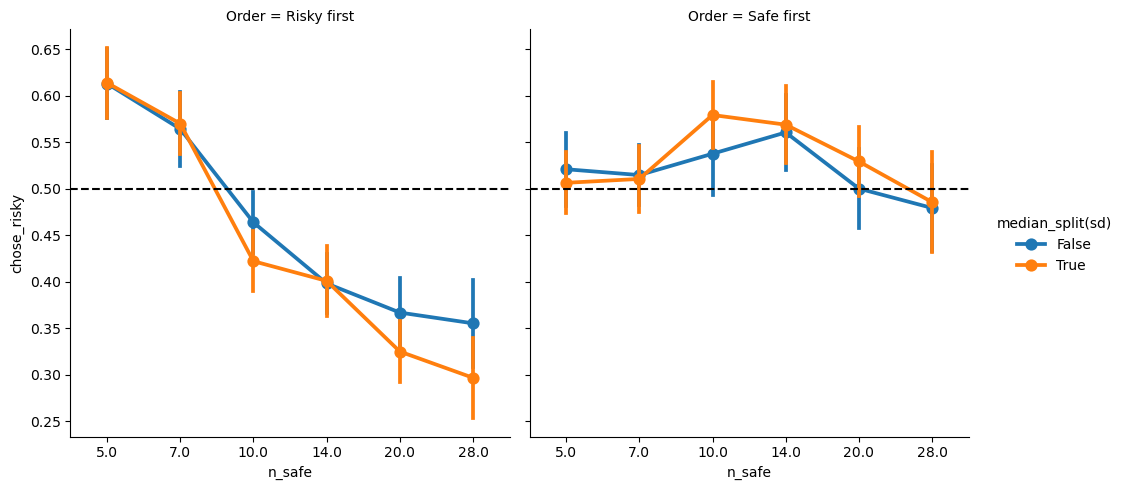

In [67]:
import matplotlib.pyplot as plt
tmp = df.groupby(['subject', 'median_split(sd)', 'Order', 'n_safe'])[['chose_risky']].mean().reset_index()

g = sns.catplot(data=tmp, x='n_safe', y='chose_risky', hue='median_split(sd)', col='Order', kind='point', errorbar='se')
g.map(plt.axhline, y=0.5, c='k', ls='--')

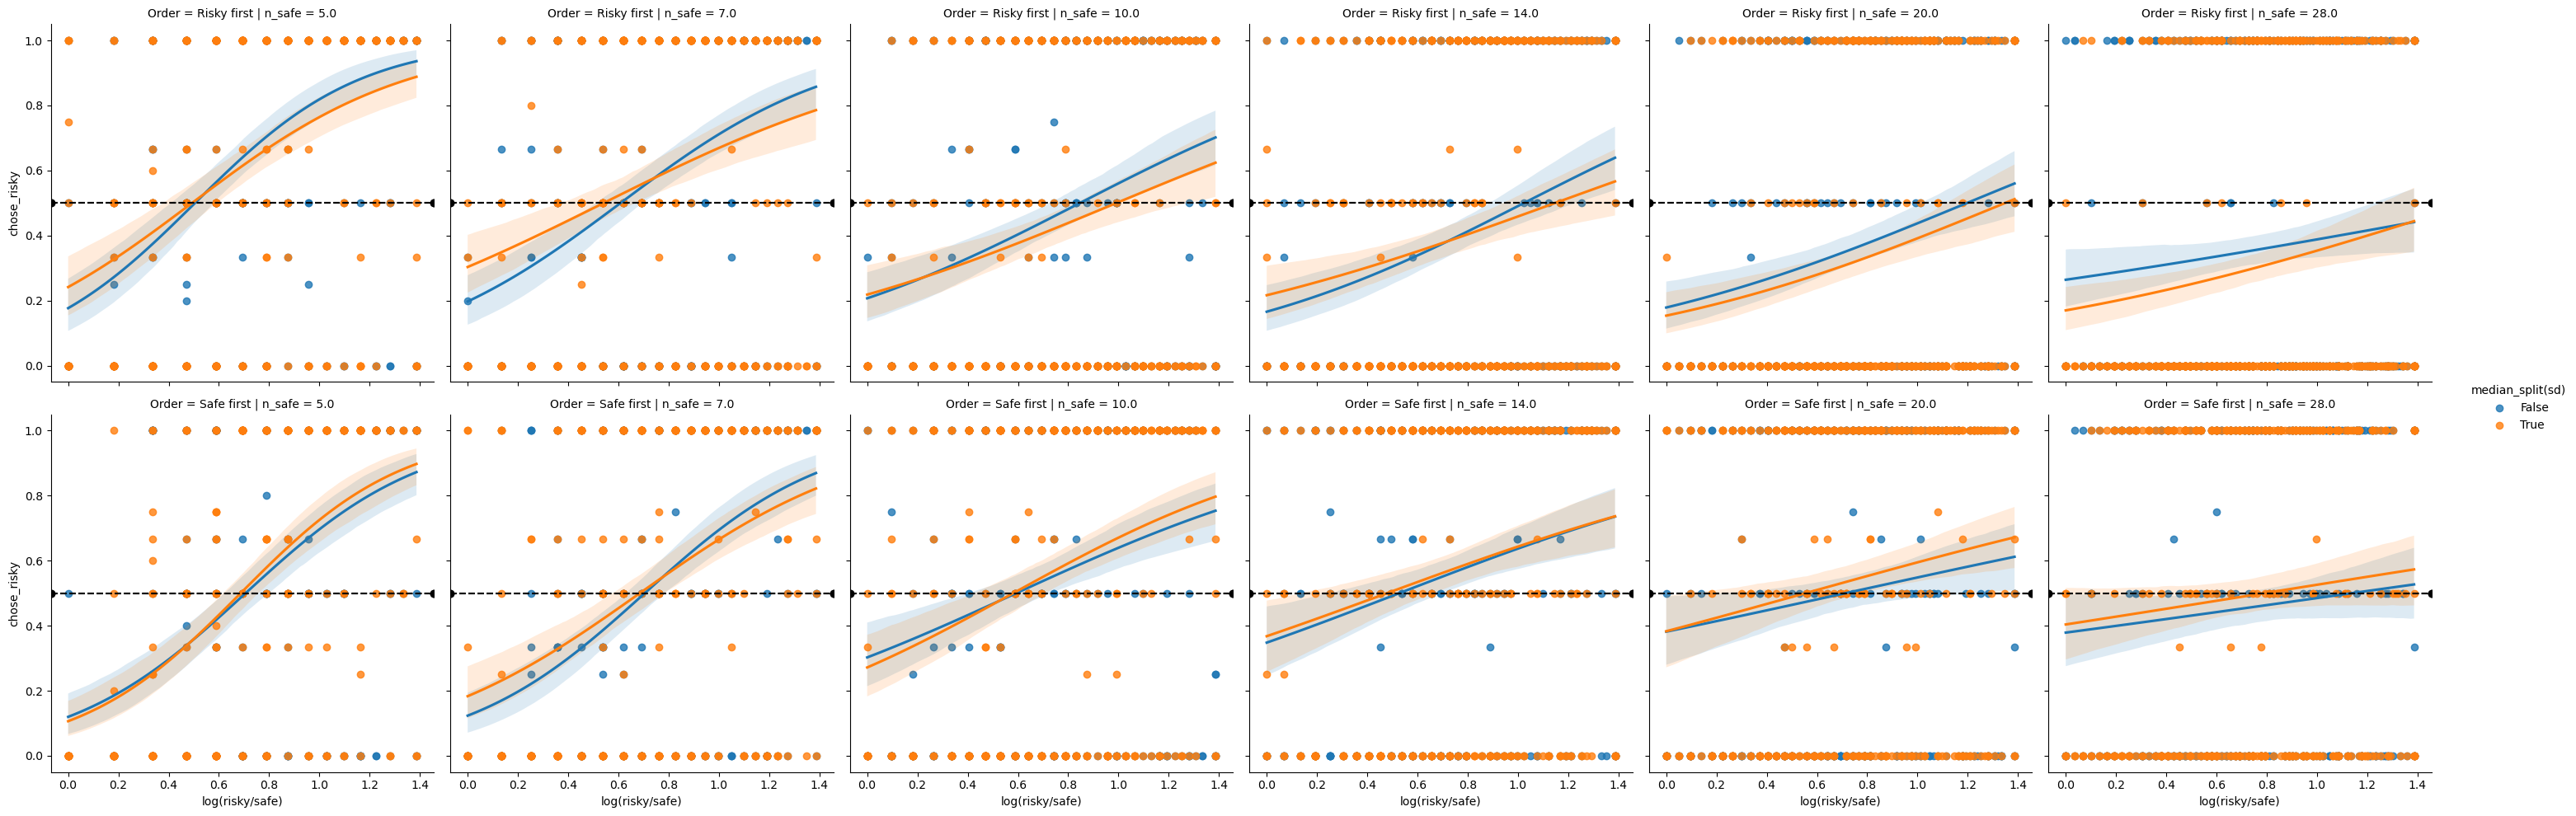

In [60]:
import matplotlib.pyplot as plt
tmp = df.groupby(['subject', 'median_split(sd)', 'Order', 'n_safe', 'log(risky/safe)'])[['chose_risky']].mean().reset_index()

g = sns.lmplot(data=tmp, x='log(risky/safe)', y='chose_risky', hue='median_split(sd)', col='n_safe', row='Order', logistic=True)
g.map(plt.axhline, y=0.5, c='k', ls='--')

In [77]:
df['median_split(E)'] = df.groupby(['subject', 'session', 'n1'], group_keys=False)['E'].apply(lambda d: d>d.quantile()).map({True:'Higher decoded', False:'Lower decoded'})

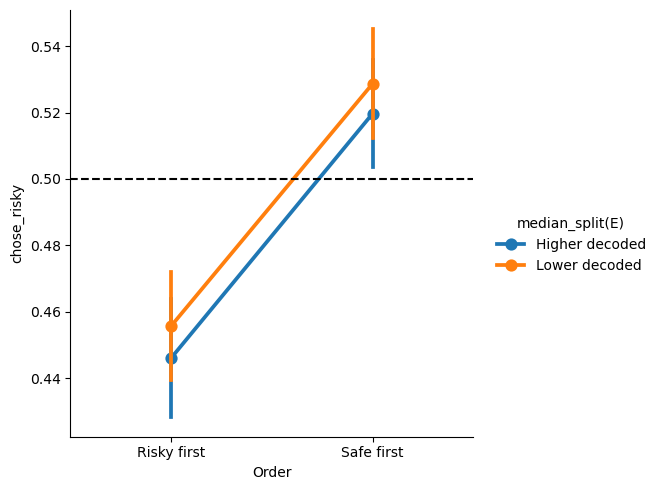

In [78]:
import matplotlib.pyplot as plt
tmp = df.groupby(['subject', 'median_split(E)', 'Order', 'n_safe'])[['chose_risky']].mean().reset_index()

g = sns.catplot(data=tmp, x='Order', y='chose_risky', hue='median_split(E)', kind='point', errorbar='se')
g.map(plt.axhline, y=0.5, c='k', ls='--')